# Logistic Model

## Importaciones

In [1]:
import time
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.linear_model import LogisticRegression

In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold

In [6]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

## Cargado de datos

In [7]:
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((170152, 14), (42539, 14), (170152, 1), (42539, 1))

In [9]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

## Funciones usadas

In [10]:
from funciones import *

## modelo logistico benchmark 

In [11]:
pipe_logit = crear_pipeline(LogisticRegression(max_iter=1000,random_state=0,multi_class='ovr',solver='saga',penalty='elasticnet',l1_ratio=0.5), tipo="normal")

In [12]:
start = time.time()
model_pipe=pipe_logit.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.09 minutos


se evalua el modelo benchmark para revisar sus metricas 

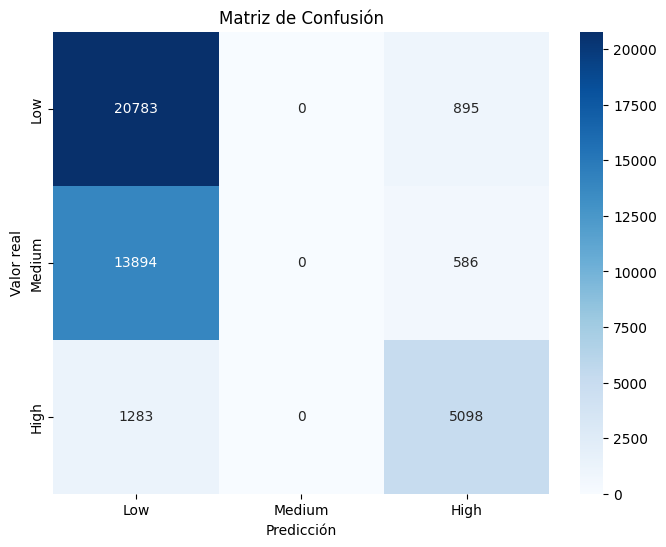


Classification Report:

              precision    recall  f1-score   support

         Low       0.58      0.96      0.72     21678
      Medium       0.00      0.00      0.00     14480
        High       0.77      0.80      0.79      6381

    accuracy                           0.61     42539
   macro avg       0.45      0.59      0.50     42539
weighted avg       0.41      0.61      0.49     42539



{'Accuracy': 0.6084064035355791,
 'Precision (macro)': 0.4509458401900453,
 'Recall (macro)': 0.5858827466025186,
 'F1-score (macro)': 0.5026281922491407,
 'ROC-AUC': 0.7198865972747441}

In [13]:
evaluar_modelo(model_pipe,X_test,y_test)

Podemos observar que en la version normal del modelode logistic el modelo tiene buenos scores en Low y High sobre todo en la metrica de recall pero no detecta medium de ninguna manera, no hay scores de medium, lo que tambien se observa en su matriz de confusion ya que ningun elemento de medium fue predicho correctamente siendo la mayoria predichos como low erroneamente. esto se puede deber al desbalanceo del modelo

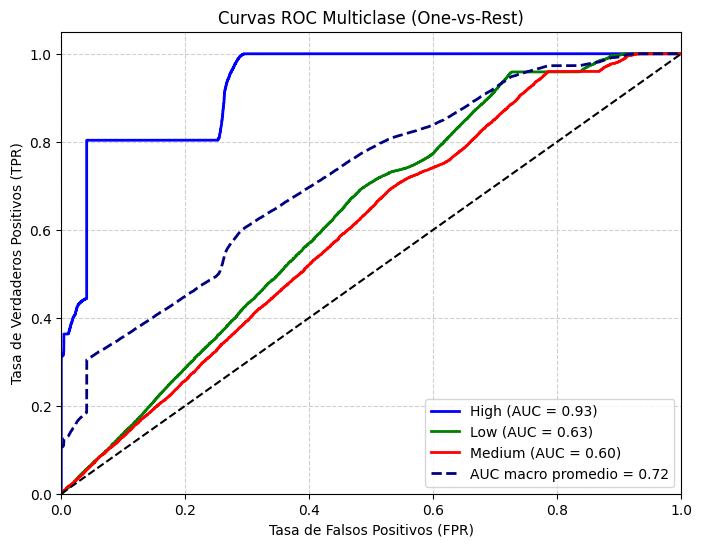


===== AUC por clase =====
High: 0.9310
Low: 0.6289
Medium: 0.5998
AUC macro promedio: 0.7199


({0: 0.9309939046792135, 1: 0.6288561383894864, 2: 0.5998097487555327},
 0.7199048666102492)

In [14]:
plot_roc_multiclass(model_pipe,X_test,y_test)

El modelo muestra un excelente desempeño para la clase “High” (AUC = 0.9579), lo que indica una alta capacidad para identificar correctamente los casos de alto riesgo.
Sin embargo, las clases “Low” (0.6377) y “Medium” (0.6061) presentan un rendimiento moderado a bajo, reflejando cierta dificultad para distinguir entre niveles de riesgo menos severos.

El AUC macro promedio (0.733) confirma un rendimiento global aceptable, aunque con margen de mejora en la diferenciación de las clases minoritarias.

Podemos observar que los AUC de las 3 clases en el modelo logistico normal benchmark tiene High es la que tiene mejor capacidad discriminatoria entre clases a diferencia del resto, con Low y medium tienen mas dificultades para separar las clases, con scores mas bajos de 0.64 y 0.61, por lo que se debe tomar en cuenta para mas adelante

## balanceo

Se aplico el balanceo mediante SMOTE y ADASYN para determinar si mejora el modelo

### SMOTE

In [15]:
pipe_logit_bal = crear_pipeline(LogisticRegression(max_iter=1000,random_state=0,multi_class='ovr',solver='saga',penalty='elasticnet',l1_ratio=0.5), tipo="balanceo_smote")

In [16]:
start = time.time()
model_bal=pipe_logit_bal.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.24 minutos


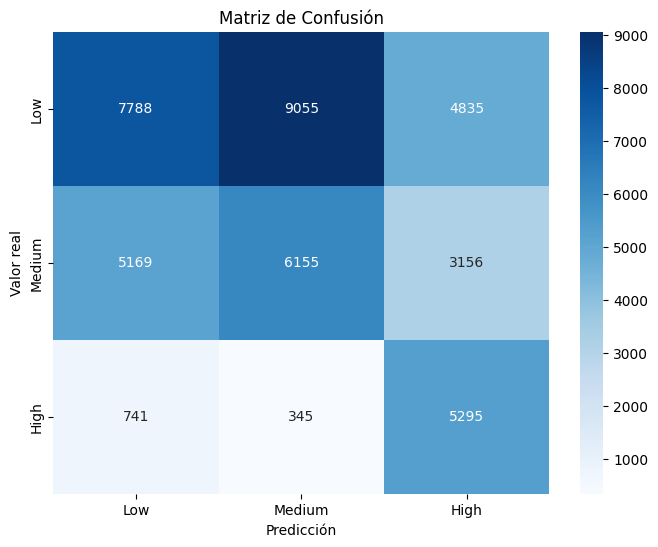


Classification Report:

              precision    recall  f1-score   support

         Low       0.57      0.36      0.44     21678
      Medium       0.40      0.43      0.41     14480
        High       0.40      0.83      0.54      6381

    accuracy                           0.45     42539
   macro avg       0.45      0.54      0.46     42539
weighted avg       0.48      0.45      0.44     42539



{'Accuracy': 0.45224382331507557,
 'Precision (macro)': 0.45426089098864003,
 'Recall (macro)': 0.5380448450574663,
 'F1-score (macro)': 0.4628730420567874,
 'ROC-AUC': 0.721600346117508}

In [17]:
evaluar_modelo(model_bal,X_test,y_test)

Podemos observar que ahora que el modelo no esta sesgado hacia Low su recall bajo pero el modelo generaliza de mejor manera, el modelo tambien ahora reconoce casi la mitad de los mediums lo cual es una mejora notable, ademas el recall de high se mantiene fuerte y hasta aumenta pero perdio algo de precision

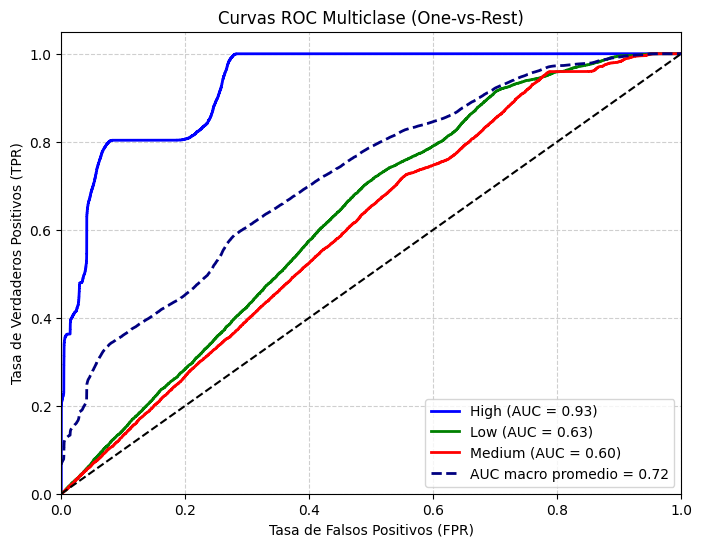


===== AUC por clase =====
High: 0.9322
Low: 0.6303
Medium: 0.6023
AUC macro promedio: 0.7216


({0: 0.932183216430554, 1: 0.6302879197958463, 2: 0.6023299021261237},
 0.7216186700405132)

In [18]:
plot_roc_multiclass(model_bal,X_test,y_test)

Podemos observar que los AUC de cada modelo no cambiaron demasiado a comparacion del modelo anterior, teniendo valores relativamente similares 

### ADASYN

Se prueba con ADASYN para revisar si generan mejores resultados

In [19]:
pipe_logit_ads = crear_pipeline(LogisticRegression(max_iter=1000,random_state=0,multi_class='ovr',solver='saga',penalty='elasticnet',l1_ratio=0.5), tipo="balanceo_adasyn")

In [20]:
start = time.time()
model_ads=pipe_logit_ads.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.40 minutos


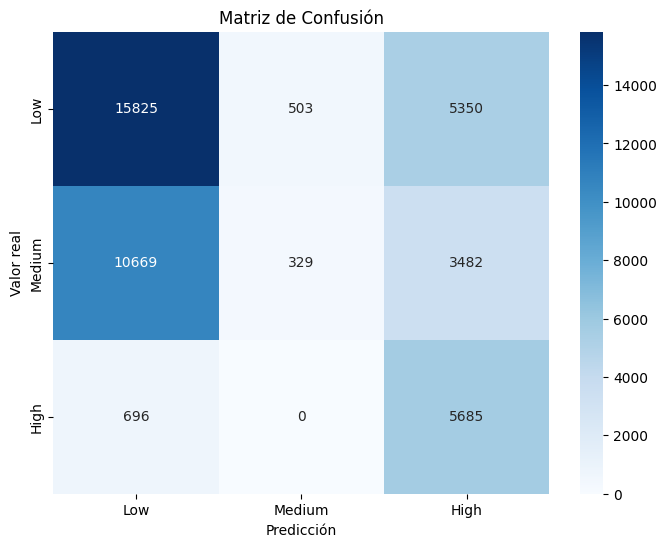


Classification Report:

              precision    recall  f1-score   support

         Low       0.58      0.73      0.65     21678
      Medium       0.40      0.02      0.04     14480
        High       0.39      0.89      0.54      6381

    accuracy                           0.51     42539
   macro avg       0.46      0.55      0.41     42539
weighted avg       0.49      0.51      0.43     42539



{'Accuracy': 0.5133877148028868,
 'Precision (macro)': 0.45635265863542757,
 'Recall (macro)': 0.5478833164587168,
 'F1-score (macro)': 0.4115690423880265,
 'ROC-AUC': 0.7227956325063754}

In [21]:
evaluar_modelo(model_ads,X_test,y_test)

Podemos observar que si bien el modelo se beneficio nuevamente de Low y High se dejo por de lado a medium en cuanto a recall, casi nunca se detecta dicha clase por lo que ADASYN reforzo la deteccion de High pero dejo de lado a medium en cuanto a recall se refiere, por lo que a comparacion de SMOTE al realizar el balanceo no pudo mejorar la situacion 

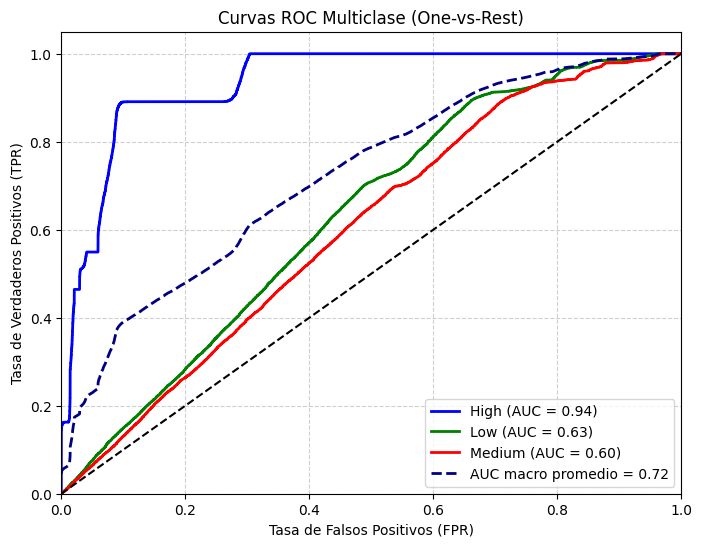


===== AUC por clase =====
High: 0.9350
Low: 0.6307
Medium: 0.6027
AUC macro promedio: 0.7228


({0: 0.9350357304091702, 1: 0.6306896580836912, 2: 0.6026615090262645},
 0.7228146465644232)

In [22]:
plot_roc_multiclass(model_ads,X_test,y_test)

El modelo muestra un excelente desempeño para la clase “High” (AUC = 0.9610), lo que indica una alta capacidad para identificar correctamente los casos de alto riesgo.
Sin embargo, las clases “Low” (0.6397) y “Medium” (0.6082) presentan un rendimiento moderado a bajo, reflejando cierta dificultad para distinguir entre niveles de riesgo menos severos.

El AUC macro promedio (0.736) confirma un rendimiento global aceptable, aunque con margen de mejora en la diferenciación de las clases minoritarias.

### Class weight balanced

In [23]:
pipe_logit_cw = crear_pipeline(LogisticRegression(max_iter=1000,random_state=0,multi_class='ovr',class_weight='balanced',penalty='elasticnet',l1_ratio=0.5,solver='saga'), tipo="normal")

In [24]:
start = time.time()
model_cw=pipe_logit_cw.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.10 minutos


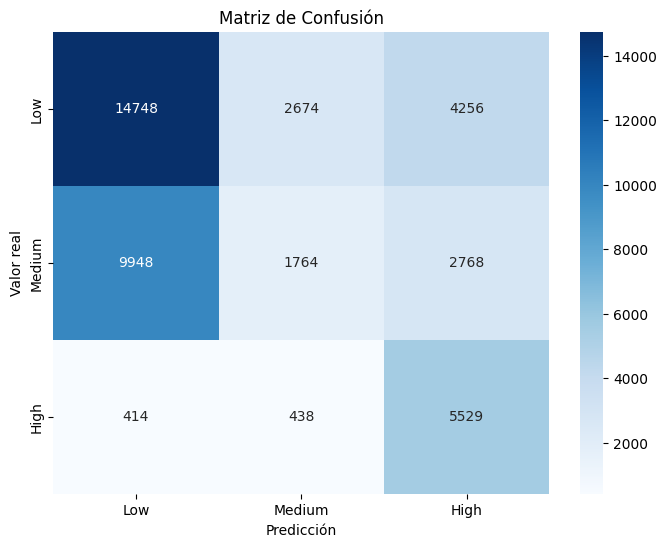


Classification Report:

              precision    recall  f1-score   support

         Low       0.59      0.68      0.63     21678
      Medium       0.36      0.12      0.18     14480
        High       0.44      0.87      0.58      6381

    accuracy                           0.52     42539
   macro avg       0.46      0.56      0.47     42539
weighted avg       0.49      0.52      0.47     42539



{'Accuracy': 0.5181362984555349,
 'Precision (macro)': 0.46318671617156526,
 'Recall (macro)': 0.5562076252057193,
 'F1-score (macro)': 0.46557195038354626,
 'ROC-AUC': 0.7225153830984881}

In [25]:
evaluar_modelo(model_cw,X_test,y_test)

Podemos observar que si bien, el recall de Low y High es excelente y medium no es 0 igual tiene scores bastante bajos en comparacion a las otras clases, con medium en 0.15 de recall y low en 0.73 

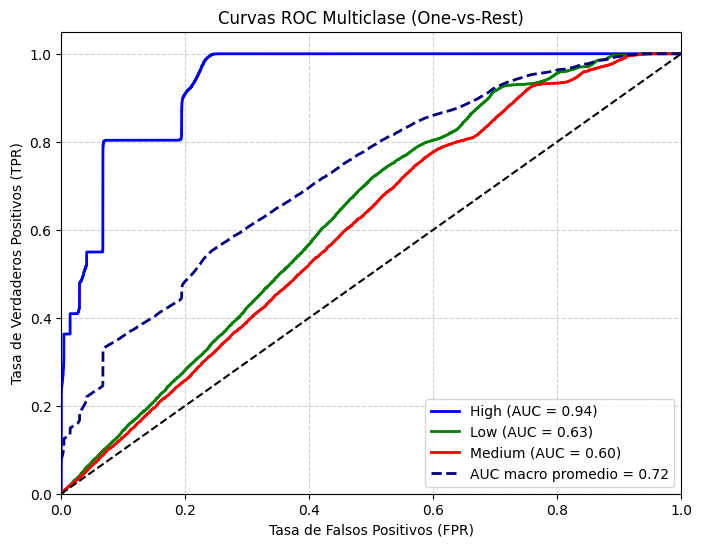


===== AUC por clase =====
High: 0.9365
Low: 0.6296
Medium: 0.6015
AUC macro promedio: 0.7225


({0: 0.936485079904796, 1: 0.6295705243099494, 2: 0.6014905450807189},
 0.7225344016661113)

In [26]:
plot_roc_multiclass(model_cw,X_test,y_test)

El modelo muestra un excelente desempeño para la clase “High” (AUC = 0.9619), lo que indica una alta capacidad para identificar correctamente los casos de alto riesgo.
Sin embargo, las clases “Low” (0.6377) y “Medium” (0.6070) presentan un rendimiento moderado a bajo, reflejando cierta dificultad para distinguir entre niveles de riesgo menos severos.

El AUC macro promedio (0.735) confirma un rendimiento global aceptable, aunque con margen de mejora en la diferenciación de las clases minoritarias.

como podemos ver, en si no es que cambie mucho en comparacion a los anteriores

## Tabla comparativa

| LogisticRegression       | Accuracy | Precision_macro | Recall_macro | F1-macro | AUC  | Tiempo en minutos
|---------------|----------|----------|--------|----------|------|------|
| Benchmark      | 0.59     | 0.42     | 0.57   | 0.48     | 0.73 | 0.10
| SMOTE     | 0.51     | 0.53     | 0.61   | 0.55     | 0.74 | 0.23
| ADASYN     | 0.58    | 0.51     | 0.60   | 0.48     | 0.74 |0.36 
| class_weight     | 0.56     | 0.52     | 0.61   | 0.53     | 0.73 | 0.09

Entre los modelos de LogisticRegression realizados se pudo observar que SMOTE es el mejor de entre todos, teniendo un mejor balance entre todas las clases en general y tiene mayor recall a comparacion de los otros